In [1]:
import os
import pandas as pd
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch
import torch.optim as optim
from torchvision import transforms
from tqdm import tqdm

In [2]:
# === Config ===
train_csv = 'csv/train.csv'
val_csv = 'csv/val.csv'
test_csv = 'csv/test.csv'
img_size = 224
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
# === Dataset ===
class SeasonDataset(Dataset):
    def __init__(self, csv_file, transform=None, label_encoder=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.le = label_encoder or LabelEncoder()
        self.data['label_encoded'] = self.le.fit_transform(self.data['label'])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join('', row['file_path'].replace("\\", "/"))
        label = row['label_encoded']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

import torch.nn.functional as F
import torch.nn as nn

class FAFLPlusLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=1.0):
        super(FAFLPlusLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        loss = self.alpha * ((1 - pt) ** self.gamma) * ce_loss
        return loss.mean()


In [4]:
# === Transforms ===
train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Validation/Test transforms remain the same
basic_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# === Label Encoder Shared ===
all_labels = pd.read_csv(train_csv)['label'].tolist()
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

# === Load Data ===
train_dataset = SeasonDataset(train_csv, train_transform, label_encoder)
val_dataset = SeasonDataset(val_csv, basic_transform, label_encoder)  # Fixed
test_dataset = SeasonDataset(test_csv, basic_transform, label_encoder)  # Fixed

train_loader = DataLoader(train_dataset, batch_size=32, num_workers=0, shuffle=True, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, num_workers=0, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, num_workers=0, shuffle=False, pin_memory=True)

In [5]:
from torchvision.models import convnext_base, ConvNeXt_Base_Weights
import torch.nn as nn

model = convnext_base(weights=ConvNeXt_Base_Weights.DEFAULT)

in_features = model.classifier[2].in_features
model.classifier = nn.Sequential(
    nn.Flatten(1),
    nn.Dropout(p=0.5),
    nn.Linear(in_features, len(label_encoder.classes_))
)

model = model.to(device)

# === Loss & Optimizer ===
criterion = FAFLPlusLoss(alpha=1.0, gamma=1.0)

optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

# === Training Loop ===
def evaluate(model, dataloader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total


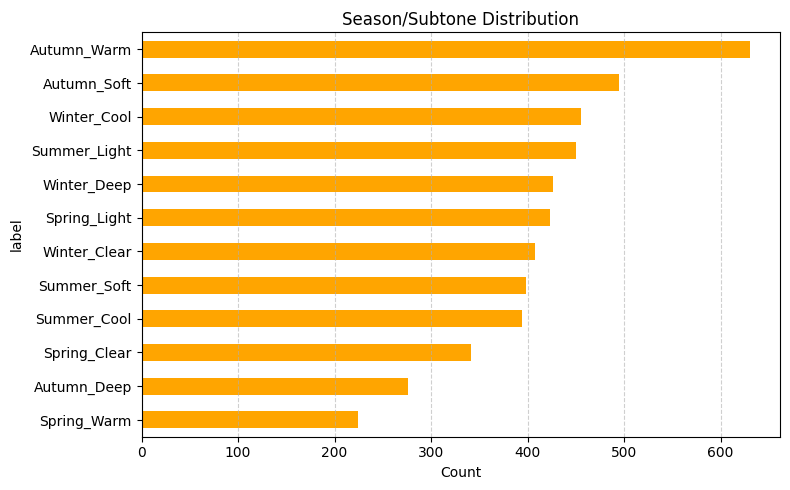

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your full dataset (train + val + test) to check total imbalance
df_train = pd.read_csv('csv/train.csv')
df_val = pd.read_csv('csv/val.csv')
df_test = pd.read_csv('csv/test.csv')

# Combine all data
df_all = pd.concat([df_train, df_val, df_test])

# Count labels
label_counts = df_all['label'].value_counts().sort_values(ascending=True)

# Plot
plt.figure(figsize=(8, 5))
label_counts.plot(kind='barh', color='orange')
plt.title('Season/Subtone Distribution')
plt.xlabel('Count')
plt.tight_layout()
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.show()


In [6]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_acc = 0.0
epochs_no_improve = 0
patience = 5
epochs = 30

print("Training with label smoothing only...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # === Validation ===
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss = criterion(outputs, labels)
            val_running_loss += val_loss.item()

            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train: Loss={train_loss:.4f}, Acc={train_acc:.4f} | "
          f"Val: Loss={val_loss:.4f}, Acc={val_acc:.4f}")

    # === Save best model ===
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs("model", exist_ok=True)
        model_path = "model/color_convnext_fafl.pth"
        torch.save(model.state_dict(), model_path)
        print(f"Best model saved at Epoch {epoch+1}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")

    scheduler.step()

    # === Early stopping ===
    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break

Training with label smoothing only...


100%|██████████| 108/108 [00:47<00:00,  2.29it/s]


Epoch 1/30 | Train: Loss=1.3427, Acc=0.4181 | Val: Loss=0.7520, Acc=0.6344
Best model saved at Epoch 1


100%|██████████| 108/108 [00:48<00:00,  2.23it/s]


Epoch 2/30 | Train: Loss=0.9319, Acc=0.5630 | Val: Loss=0.8286, Acc=0.6180
No improvement for 1 epoch(s)


...

Epoch 21/30 | Train: Loss=0.3302, Acc=0.8139 | Val: Loss=0.6049, Acc=0.7271
No improvement for 3 epoch(s)


100%|██████████| 108/108 [00:48<00:00,  2.21it/s]


Epoch 22/30 | Train: Loss=0.2910, Acc=0.8395 | Val: Loss=0.6334, Acc=0.7203
No improvement for 4 epoch(s)


100%|██████████| 108/108 [00:48<00:00,  2.21it/s]


Epoch 23/30 | Train: Loss=0.2803, Acc=0.8421 | Val: Loss=0.6534, Acc=0.7231
No improvement for 5 epoch(s)
Early stopping triggered.


In [7]:
# === Final Test Accuracy ===
test_acc = evaluate(model, test_loader)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.7179


In [7]:
model.load_state_dict(torch.load('models/color_convnext_fafl.pth'))
model.eval()

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (1): Permute()
          (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=128, out_features=512, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=512, out_features=128, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (1): Permute()
          (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (3): Linear(

In [8]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Acc')
plt.plot(epochs_range, val_accuracies, label='Val Acc')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'train_losses' is not defined

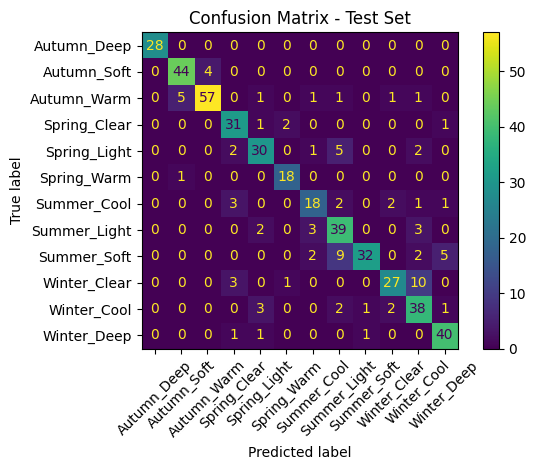

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.load_state_dict(torch.load("models/color_convnext_fafl.pth"))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())


cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

In [11]:
# === Predict new image ===
from PIL import Image

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = train_transform(image).unsqueeze(0).to(device)

    model.load_state_dict(torch.load("model/color_convnext_based.pth", map_location=device))
    model.eval()

    with torch.no_grad():
        output = model(image)
        pred_idx = output.argmax(dim=1).item()
        label = label_encoder.inverse_transform([pred_idx])[0]

    print(f"Predicted Seasonal Tone: {label}")
    return label

# === Example usage ===
predict_image("../clustered_seasons_kmeans/Winter/Deep/14311.png")

Predicted Seasonal Tone: Winter_Deep


'Winter_Deep'